# Band-averaged spectral energy as a function of time

Three-panel plot (large / medium / small scales) showing the mean spectral
energy in each wavenumber band over the full rollout, with the climatological
envelope as a grey shading.

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

import sys
sys.path.insert(0, str(Path('..').resolve()))
from utils import SMALL_BANDS, MEDIUM_BANDS, LARGE_BANDS

Parameters

In [2]:
model_name  = 'Aurora'

# Temporal downsampling ratio (R=4 → one point per day)
R = 4

COLOR_MODEL = {
    'ERA5':         'black',
    'Aurora':       'tab:cyan',
    'SFNO':         'tab:green',
    'Pangu':        'tab:pink',
    'GraphCast':    'tab:purple',
    'FourCastNet':  'tab:olive',
    'FuXi':         'tab:brown',
    'AIFS':         'tab:red',
    'GenCast':      'tab:orange',
}

Load energy spectra

In [ ]:
spectrum_pred_path = Path(f'/path/to/Fourier_spectrum_{model_name}.nc')
spectrum_era5_path = Path('/path/to/Fourier_spectrum_target.nc')
spectrum_era5_clim_path = Path('/path/to/Fourier_spectrum_clim.nc')

spectrum_pred   = xr.open_dataset(spectrum_pred_path)
spectrum_target = xr.open_dataset(spectrum_era5_path)
spectrum_clim = xr.open_dataset(spectrum_era5_clim_path)


# Build climatological mean and range
clim_smooth = spectrum_clim.rolling(time=16, center=True).mean()
clim_mean   = clim_smooth.groupby(['time.dayofyear', 'time.hour']).mean()
clim_range  = (
    clim_smooth.groupby(['time.dayofyear', 'time.hour']).max()
  - clim_smooth.groupby(['time.dayofyear', 'time.hour']).min()
)

# Down-sampled time axes
xvalues      = spectrum_target.time[::R]
xvalues_pred = spectrum_pred.time[::R]

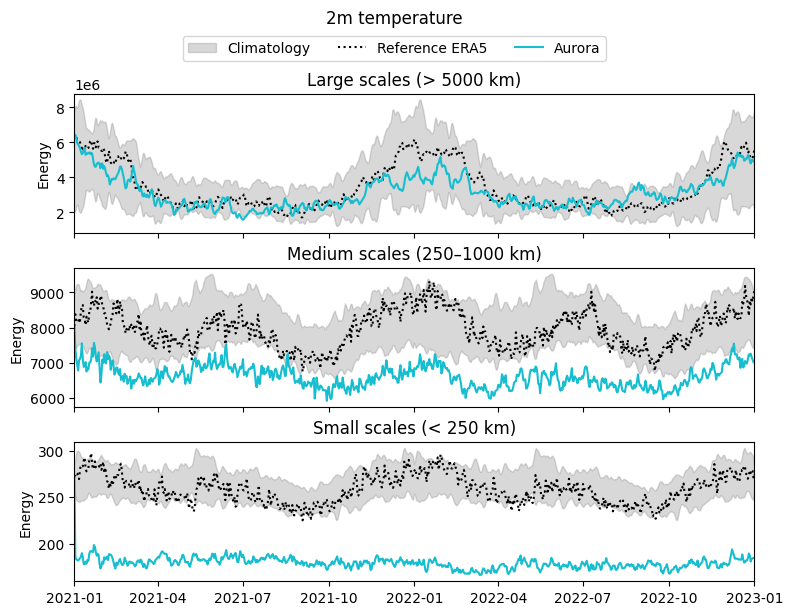

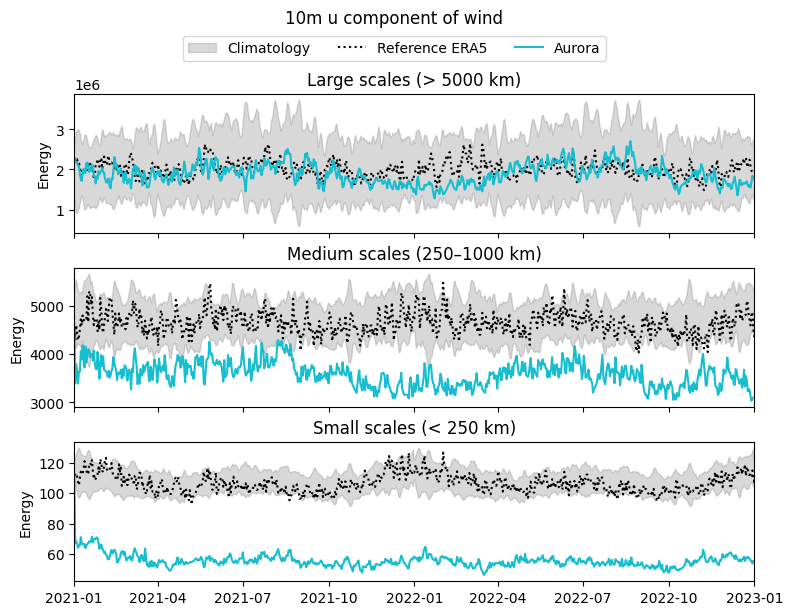

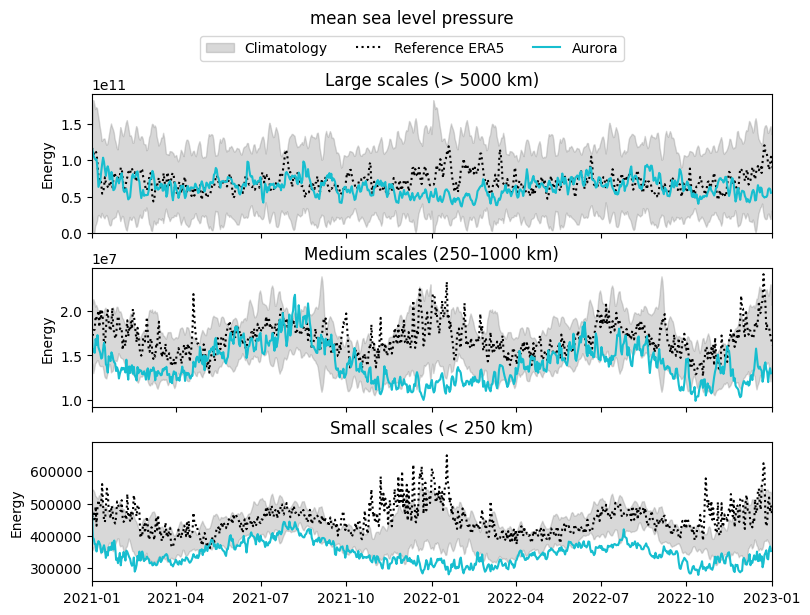

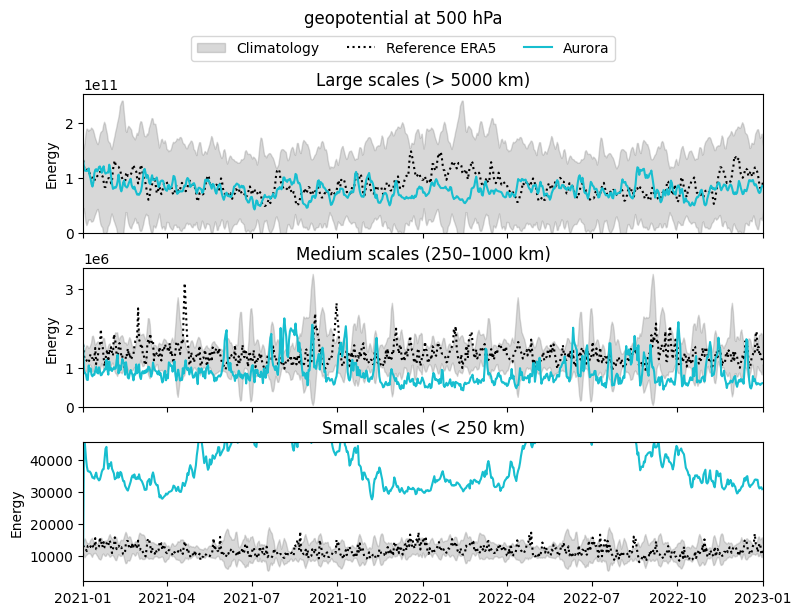

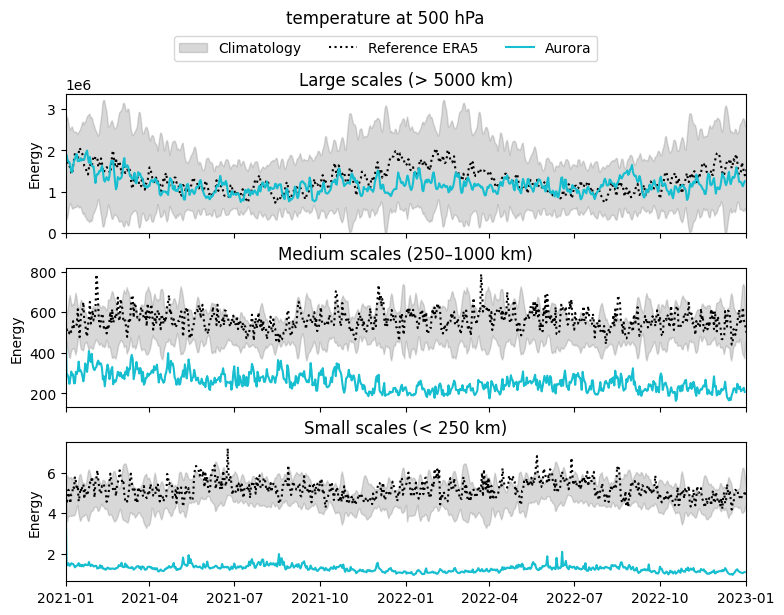

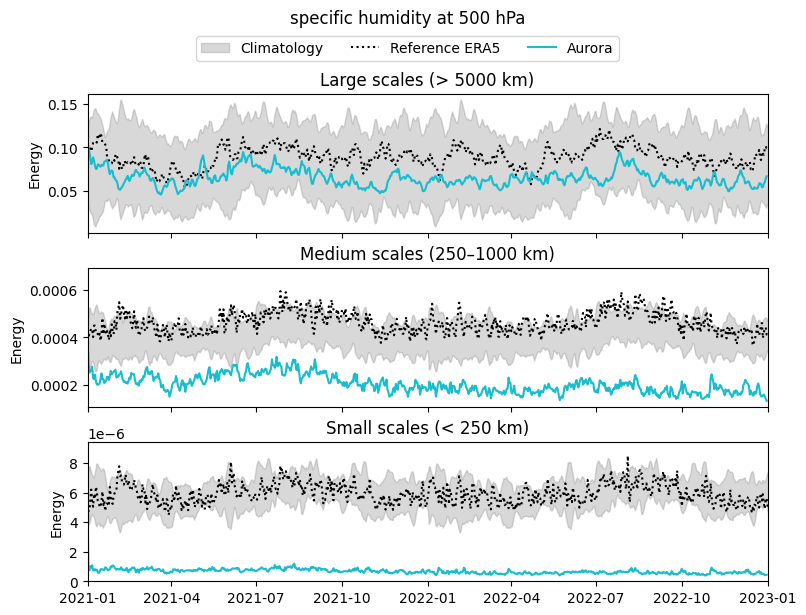

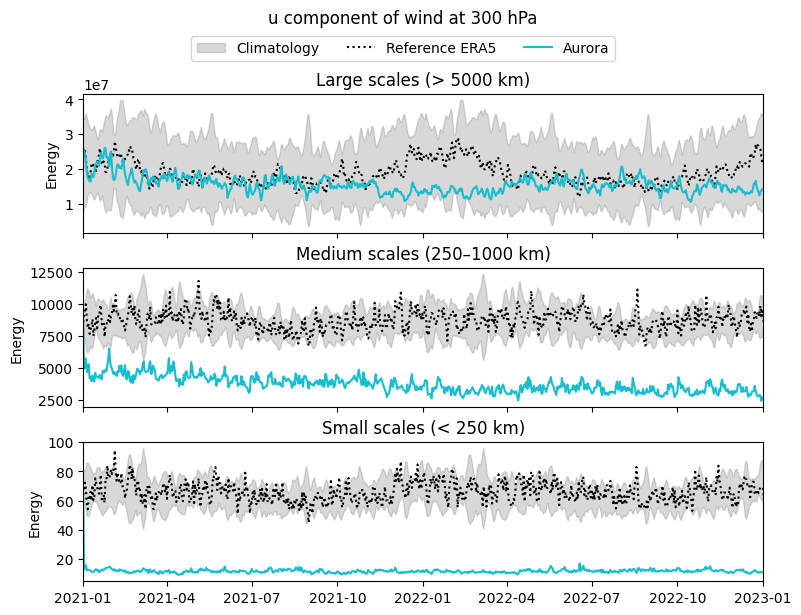

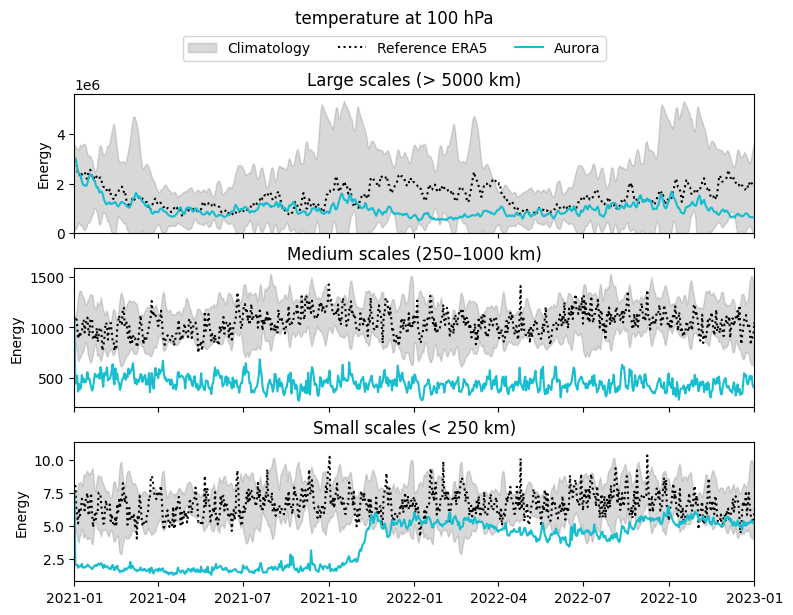

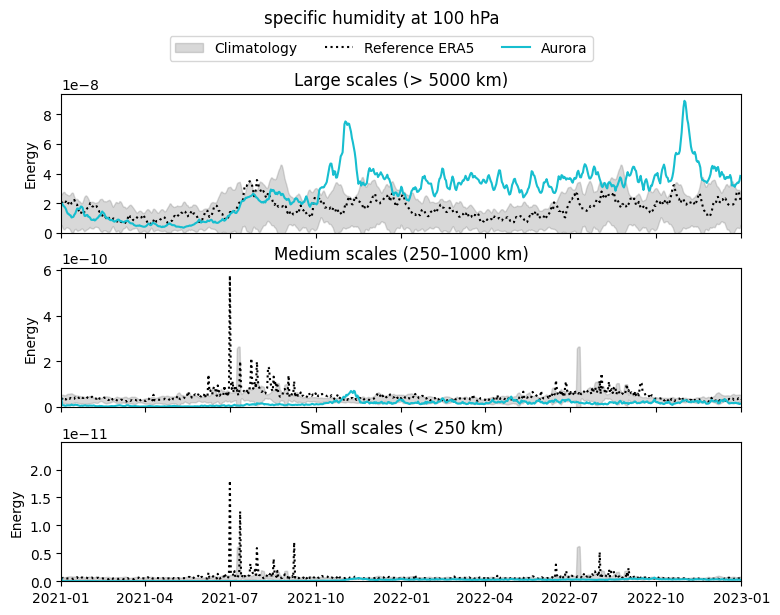

In [5]:
def _band_mean(ds, bands, times):
    """Mean spectrum over a wavelength band at given times."""
    return (
        ds.sel(time=times, wavenumber=slice(1/bands[1], 1/bands[0]))
          .mean(dim='wavenumber')
    )

def _clim_band(clim, sign, bands, times):
    """Climatological envelope (mean ± range) for a band, aligned to times."""
    doy  = times.dt.dayofyear
    hour = times.dt.hour
    return (
        (clim_mean + sign * clim_range)
        .sel(dayofyear=doy, hour=hour, wavenumber=slice(1/bands[1], 1/bands[0]))
        .mean(dim='wavenumber')
    )

color = COLOR_MODEL.get(model_name, 'tab:blue')

BANDS = [
    (LARGE_BANDS,  f'Large scales (> {LARGE_BANDS[0]} km)'),
    (MEDIUM_BANDS, f'Medium scales ({MEDIUM_BANDS[0]}–{MEDIUM_BANDS[1]} km)'),
    (SMALL_BANDS,  f'Small scales (< {SMALL_BANDS[1]} km)'),
]

for var in spectrum_pred.data_vars:
    fig, axs = plt.subplots(3, 1, figsize=(8, 6.5), sharex=True, dpi=100)
    fig.subplots_adjust(left=0.1, bottom=0.1, right=0.95, top=0.85, hspace=0.25)

    for ax, (bands, title) in zip(axs, BANDS):
        # Climatological envelope
        env_lo = _clim_band(clim_mean, -1, bands, xvalues)[var]
        env_hi = _clim_band(clim_mean, +1, bands, xvalues)[var]
        ax.fill_between(xvalues, env_lo, env_hi,
                        color='tab:grey', alpha=0.3, label='Climatology' if ax == axs[0] else '_nolegend_')

        # ERA5 target
        ax.plot(xvalues, _band_mean(spectrum_target, bands, xvalues)[var],
                'k:', label='Reference ERA5' if ax == axs[0] else '_nolegend_')
        ylims_ref = ax.get_ylim()

        # Model prediction
        ax.plot(xvalues_pred, _band_mean(spectrum_pred, bands, xvalues_pred)[var],
                color=color, label=model_name if ax == axs[0] else '_nolegend_')
        ylims_pred = ax.get_ylim()

        ax.set_ylim([
            max(0, min(ylims_ref[0], ylims_pred[0])),
            min(ylims_pred[1], 2 * ylims_ref[1]),
        ])
        ax.set_ylabel('Energy')
        ax.set_title(title)

    axs[-1].set_xlim([np.datetime64('2021-01-01'), np.datetime64('2023-01-01')])
    fig.legend(loc='upper center', ncols=3, bbox_to_anchor=(0.5, 0.95))

    parts = var.rsplit('_', 1)
    if len(parts) == 2 and parts[1].isdigit():
        fig.suptitle(f"{parts[0].replace('_', ' ')} at {parts[1]} hPa")
    else:
        fig.suptitle(var.replace('_', ' '))

    plt.show()